In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad("/data7/mark/STG/dataset/snRNA/merge_SCH_new/CSRES_4v3_500_1000gene/TH_downsampled.h5ad")

In [3]:
adata.obs["celltype.L2"].value_counts()

celltype.L2
Astrocyte-1                5724
TH Tll1_Thsd7b Glut        4821
TH Tnc_Cdh20 Glut          4352
TH Car4_Tspan11 Glut       4211
TH Cald1_Gm39185 Glut      3249
TH Fam20a_Fbln1 Glut       2954
MOL-1                      2719
MOL-2                      2279
OPC                        2167
TH Kcnk13_Nox4 Glut        2147
TH Ccdc192_Gli3 Glut       2023
TH Meis2_Gm2115 GABA       1988
TH Parm1_Mdga1 Glut        1497
TH Fgf10_Gm16263 Glut      1332
MOL-3                      1215
TH Egflam_Fbn2 Glut        1113
MFOL                        601
TH Tac2_Pde11a Glut         311
Astrocyte-3                 284
Choroid plexus cell         274
COP                         237
TH Col27a1_Npsr1 Glut       190
Astrocyte-4                 149
Microglia-1                 141
Ependymal cell              119
NFOL                         65
Microglia-2                  57
Tanycyte                     56
VLMC                         41
Endothelial cell             33
Astrocyte-2                 

In [4]:
adata_subset = adata[adata.obs["celltype.L2"].isin(["TH Tll1_Thsd7b Glut"])]
#去掉名字包含MW22B的样本
adata_subset = adata_subset[~adata_subset.obs["sample"].str.contains("MW22B")]

In [5]:
# 探索 subset 数据结构
print(f"adata_subset shape: {adata_subset.shape}")
print(f"Obs columns: {list(adata_subset.obs.columns)}")
print(f"X type: {type(adata_subset.X)}")
print(f"X min/max: {adata_subset.X.min():.4f} / {adata_subset.X.max():.4f}")
print(f"细胞数量: {adata_subset.n_obs}")
print(f"基因数量: {adata_subset.n_vars}")
print()
# 查看分组信息
print("celltype.L2 value counts:")
print(adata_subset.obs["celltype.L2"].value_counts())
print()
# 查看是否有 batch 信息
for col in adata_subset.obs.columns:
    if "batch" in col.lower():
        print(f"Batch column: {col}")
        print(adata_subset.obs[col].value_counts())

adata_subset shape: (3973, 16428)
Obs columns: ['sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'scrublet_score', 'predicted_doublets', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'date', 'status', 'sex', 'donor', 'region', 'company', 'cells_number', 'fraction_reads', 'mean_reads', 'median_umi', 'median_genes', 'total_genes', 'mapped_genome', 'mapped_confidently_genome', 'mapped_intergenic', 'mapped_intronic', 'mapped_exonic', 'mapped_transcriptome', 'antisense_gene', 'reads_number', 'valid_barcodes', 'sequencing_saturation', 'q30_barcode', 'q30_rna', 'q30_umi', 'tech', 'batch', 'predicted_labels'

In [6]:
# 查看可用于分组的列
for col in ["status", "region", "sex", "donor", "date"]:
    if col in adata_subset.obs.columns:
        print(f"\n{col} value counts:")
        print(adata_subset.obs[col].value_counts().head(20))


status value counts:
status
CSRES    2140
CON      1833
Name: count, dtype: int64

region value counts:
region
TH    3973
Name: count, dtype: int64

sex value counts:
sex
M    3973
Name: count, dtype: int64

donor value counts:
donor
CSRS1-3     928
CSRS10-3    644
MW47A       633
MW51A       619
MW45A       581
CSRS9-1     568
Name: count, dtype: int64

date value counts:
date
20250728    2140
20250102    1200
20250107     633
Name: count, dtype: int64


In [7]:
# 检查 adata 是否有 raw 或 layers
print("Has raw:", adata.raw is not None)
if hasattr(adata, 'layers'):
    print("Layers keys:", list(adata.layers.keys()))
print("adata_subset.X shape:", adata_subset.X.shape)
print("adata_subset.X type:", type(adata_subset.X))

# 检查 var 是否有基因名
print("\nvar columns:", list(adata_subset.var.columns[:20]))
print("var index head:", adata_subset.var.index[:5].tolist())

Has raw: False
Layers keys: ['counts', None]
adata_subset.X shape: (3973, 16428)
adata_subset.X type: <class 'anndata._core.views.SparseCSRMatrixView'>

var columns: ['gene_ids']
var index head: ['Xkr4', 'Gm1992', 'Gm19938', 'Rp1', 'Mrpl15']


In [8]:
import sys
sys.path.insert(0, "/home/junyichen/code/RUVAEDEG")
from model import RUVVAE_DEG, compute_deg

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

# 设置
batch_key = "batch"
group_key = "status"
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [9]:
hkg_priority = [
    "Aars", "Sars",
    "Polr2a", "Polr2f",
    "Psmd6", "Psmd7", "Psma5",
    "Rer1", "Ipo8", "Pop4", "Pes1",
    "Oaz1",
    "Rpl13a", "Rpl27", "Rps13", "Rps20",
    "Hprt1", "Gusb", "Ppia", "Ywhaz"
]

candidate_negative_control_genes = [
    # 在大规模跨组织分析中相对稳定
    "Oaz1",
    "Rps13",
    "Rps20",
    "Rpl27",

    # 小鼠脑中报告相对稳定的基础基因
    "Aars",
    "Polr2f",
    "Psmd6",
    "Psmd7",
    "Psma5",

    # RNA加工、核质运输与基础细胞维护
    "Ipo8",
    "Pop4",
    "Pes1",
    "Rer1",

    # 可作为补充候选，但必须在本数据中验证
    "Rpl13a",
    "Cyc1",
    "Sdha",
    "Ubc"
]

hkg_priority = candidate_negative_control_genes 

In [10]:
# ========== 1. 准备数据（全部基因） ==========
adata_hvg = adata_subset.copy()

# 清理数据中的 inf/nan
X_data = adata_hvg.X.toarray() if hasattr(adata_hvg.X, 'toarray') else adata_hvg.X.copy()
X_data = np.nan_to_num(X_data, nan=0.0, posinf=0.0, neginf=0.0)
adata_hvg.X = X_data

# Normalizing to median total counts
sc.pp.normalize_total(adata_hvg)
# Logarithmize the data
sc.pp.log1p(adata_hvg)

# 使用全部基因（不做 HVG 筛选）
n_genes_total = adata_hvg.n_vars
Y_all = X_data  # (n_cells, n_genes)
gene_names = adata_hvg.var.index.tolist()
print(f"基因总数: {n_genes_total}")
print(f"表达矩阵形状: {Y_all.shape}")
print(f"表达矩阵范围: {Y_all.min():.4f} ~ {Y_all.max():.4f}")

# 分组标签
group_labels = adata_hvg.obs[group_key].values
groups_unique = sorted(np.unique(group_labels).tolist())
print(f"分组: {groups_unique}")
print(f"CON: {(group_labels==groups_unique[0]).sum()}, CSDS: {(group_labels==groups_unique[1]).sum()}")

# 批次标签
batch_labels = adata_hvg.obs[batch_key].values
batches_unique = sorted(np.unique(batch_labels).tolist())
print(f"批次数量: {len(batches_unique)}")
print(f"批次: {batches_unique}")

基因总数: 16428
表达矩阵形状: (3973, 16428)
表达矩阵范围: 0.0000 ~ 7.7059
分组: ['CON', 'CSRES']
CON: 1833, CSDS: 2140
批次数量: 6
批次: ['CSRS1-3_TH_beirui', 'CSRS10-3_TH_beirui', 'CSRS9-1_TH_beirui', 'MW45A_TH_beirui', 'MW47A_TH_seekgene', 'MW51A_TH_beirui']


In [11]:
# ========== 1b. 计算 n_genes_on（每个细胞检测到的基因数，用作连续协变量） ==========
# 从 raw counts 计算每个细胞表达值 > 0 的基因数。
x_raw = adata_hvg.layers["counts"].toarray() if hasattr(adata_hvg.layers["counts"], "toarray") else adata_hvg.layers["counts"]
x_raw = np.nan_to_num(x_raw, nan=0.0, posinf=0.0, neginf=0.0)
n_genes_on_raw = (x_raw > 0).sum(axis=1).astype(np.float32)

# 连续协变量必须标准化，否则会因量纲过大导致 W_cov 不稳定。
n_genes_on_mean = float(n_genes_on_raw.mean())
n_genes_on_std = float(n_genes_on_raw.std())
if n_genes_on_std < 1e-8:
    raise ValueError("n_genes_on 没有足够变异，无法作为连续协变量")
n_genes_on = ((n_genes_on_raw - n_genes_on_mean) / n_genes_on_std).astype(np.float32)
adata_hvg.obs["n_genes_on"] = n_genes_on
print(f"n_genes_on source: raw counts > 0")
print(f"raw mean/std: {n_genes_on_mean:.1f} / {n_genes_on_std:.1f}")
print(f"standardized range: {n_genes_on.min():.3f} ~ {n_genes_on.max():.3f}")


n_genes_on source: raw counts > 0
raw mean/std: 3875.3 / 1024.6
standardized range: -2.547 ~ 3.147


In [12]:
# ========== 2. 选择负对照基因（HKG 文献池 + 数据驱动） ==========

# ---------- 用户选项：NC 选择策略 ----------
NC_MODE = "data_only"  # 选项: "data_only", "hkg_only", "hybrid"

# ---------- 2a. 定义 HKG 候选函数（适配小鼠基因名） ----------
import re

def build_candidate_nc_genes_mouse(gene_names):
    """构造候选负对照基因池（适配小鼠 gene symbol 大小写）"""
    
    # 1) 文献 curated housekeeping（Eisenberg & Levanon 2013, 转小鼠大小写）
    eisenberg_hkg = {
        "Actb", "B2m", "Gapdh", "Hmbs", "Hprt1", "Pgk1", "Ppia",
        "Rpl13a", "Rplp0", "Sdha", "Tbp", "Tfrc", "Ubc", "Vcp",
        "Ywhaz", "C1orf43", "Chmp2a", "Emc7", "Gpi", "Psmb2",
        "Psmb4", "Rab7a", "Reep5", "Snrpd3", "Vps29",
        "Cltc", "Csnk2b", "Ddx5", "Eef1a1", "Eif4a2",
        "Hnrnpk", "Nono", "Rpl32", "Rps18", "Sf3b1",
        "Srsf3", "Sumo1", "Ube2d2", "Usp22", "Xrn2",
    }
    
    # 2) 核糖体蛋白（细胞质 + 线粒体）
    rp_genes = {g for g in gene_names 
                if re.match(r'^(RP[SL]|Mrp[sl]|Rps|Rpl)[0-9]', g, re.IGNORECASE)}
    
    # 3) 翻译延伸因子
    eef_genes = {g for g in gene_names if re.match(r'^(Eef[12]|EIF)', g, re.IGNORECASE)}
    
    # 4) 蛋白酶体亚基
    psm_genes = {g for g in gene_names if re.match(r'^(Psm|PSM)[A-Da-d][0-9]', g)}
    
    # 5) 线粒体核糖体蛋白
    mrp_genes = {g for g in gene_names if re.match(r'^Mrp[sl][0-9]', g, re.IGNORECASE)}
    
    candidate = (eisenberg_hkg & set(gene_names)) | rp_genes | eef_genes | psm_genes | mrp_genes
    return np.array([g in candidate for g in gene_names])


# ---------- 2b. 计算表达矩阵 ----------
counts = adata_hvg.layers["counts"].toarray()
counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
Y_log = np.log1p(counts)

# 按 status 分组计算均值
mask_con = group_labels == groups_unique[0]
mask_csds = group_labels == groups_unique[1]
mean_con = Y_log[mask_con].mean(0)
mean_csds = Y_log[mask_csds].mean(0)
fc_abs = np.abs(mean_csds - mean_con)  # 两组间 logFC 绝对值

# ---------- 2c. 构造 HKG + 优先列表 ----------
hkg_mask = build_candidate_nc_genes_mouse(gene_names)
print(f"HKG 候选基因（文献+核糖体+蛋白酶体等）: {hkg_mask.sum()}")

# 用户自定义的优先 HKG 列表（确保它们一定在内参中）
priority_mask = np.zeros(n_genes_total, dtype=bool)
for hkg in hkg_priority:
    if hkg in gene_names:
        idx = gene_names.index(hkg)
        priority_mask[idx] = True
print(f"优先 HKG 列表命中: {priority_mask.sum()} / {len(hkg_priority)}")

# HKG 总池 = 文献候选 + 优先列表
hkg_combined_mask = hkg_mask | priority_mask

# ---------- 2d. 根据 NC_MODE 选择负对照基因 ----------
n_nc_total = 500  # 总负对照基因数

if NC_MODE == "data_only":
    # 纯数据驱动：从全部基因中挑选 logFC 最小的 n_nc_total 个
    nc_idx = np.argsort(fc_abs)[:n_nc_total]
    print(f"[模式: data_only] 从全部 {n_genes_total} 基因中按 |logFC| 排序挑 {n_nc_total} 个")

elif NC_MODE == "hkg_only":
    # 纯先验知识：只用 HKG 文献池 + 优先列表
    available_hkg_idx = np.where(hkg_combined_mask)[0]
    if len(available_hkg_idx) >= n_nc_total:
        # HKG 多于目标，按 |logFC| 排序挑最小的
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hkg_only] 从 HKG 池（{len(available_hkg_idx)}）中挑 {n_nc_total} 个")
    else:
        # HKG 不够，全部用上
        nc_idx = available_hkg_idx
        print(f"[模式: hkg_only] HKG 仅 {len(available_hkg_idx)} 个，全部用上")

elif NC_MODE == "hybrid":
    # 混合：先验 HKG + 数据驱动补足
    n_hkg = hkg_combined_mask.sum()
    if n_hkg >= n_nc_total:
        hkg_fc = fc_abs.copy()
        hkg_fc[~hkg_combined_mask] = np.inf
        nc_idx = np.argsort(hkg_fc)[:n_nc_total]
        print(f"[模式: hybrid] HKG={n_hkg} ≥ {n_nc_total}，从 HKG 中挑 |logFC| 最小的")
    else:
        remaining = n_nc_total - n_hkg
        non_hkg_fc = fc_abs.copy()
        non_hkg_fc[hkg_combined_mask] = np.inf
        data_idx = np.argsort(non_hkg_fc)[:remaining]
        nc_idx = np.concatenate([np.where(hkg_combined_mask)[0], data_idx])
        print(f"[模式: hybrid] HKG={n_hkg} 全部保留 + 数据驱动补 {remaining} 个")
else:
    raise ValueError(f"NC_MODE = {NC_MODE} 不支持，请用 'data_only' / 'hkg_only' / 'hybrid'")

neg_control_mask = np.zeros(n_genes_total, dtype=bool)
neg_control_mask[nc_idx] = True

# ---------- 2e. 打印详细统计 ----------
nc_hkg_overlap = neg_control_mask & hkg_combined_mask
nc_priority_overlap = neg_control_mask & priority_mask
print(f"\n最终负对照基因: {neg_control_mask.sum()}")
print(f"  其中 HKG 文献候选: {nc_hkg_overlap.sum()}")
print(f"  其中优先 HKG 列表: {nc_priority_overlap.sum()}")
print(f"  其中非 HKG（仅 hybrid 模式）: {neg_control_mask.sum() - nc_hkg_overlap.sum()}")
print(f"\n负对照基因 (前10): {[gene_names[i] for i in nc_idx[:10]]}")
print(f"负对照基因 logFC 范围: {fc_abs[nc_idx].min():.4f} ~ {fc_abs[nc_idx].max():.4f}")

HKG 候选基因（文献+核糖体+蛋白酶体等）: 301
优先 HKG 列表命中: 17 / 17
[模式: data_only] 从全部 16428 基因中按 |logFC| 排序挑 500 个

最终负对照基因: 500
  其中 HKG 文献候选: 7
  其中优先 HKG 列表: 0
  其中非 HKG（仅 hybrid 模式）: 493

负对照基因 (前10): ['E130119H09Rik', 'Mroh3', 'Gm45025', 'Neurod6', 'Tcp11', 'Olfr1033', 'Usp26', 'Bcl2l12', '1700007K13Rik', 'Fcgr3']
负对照基因 logFC 范围: 0.0000 ~ 0.0005


In [ ]:
# ========== 3. 训练 RUVVAE_DEG ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# 初始化模型（group 是 biology；batch 和 n_genes_on 是 nuisance covariates）
model = RUVVAE_DEG(
    n_genes=n_genes_total,
    n_group=2,
    n_batch=len(batches_unique),
    n_genes_on=1,
    d_bio=32,
    k_unk=5
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# 准备 covariate 字典
group_idx = np.array([groups_unique.index(g) for g in group_labels])
c_dict = {"group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]).to(device)}
batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
c_dict["batch"] = torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]).to(device)
c_dict["n_genes_on"] = torch.FloatTensor(n_genes_on[:, None]).to(device)

# 转换数据为 tensor
Y_t = torch.FloatTensor(Y_log).to(device)
nc_mask_t = torch.BoolTensor(neg_control_mask).to(device)

n_epochs = 200
batch_size = 256
n_cells = Y_t.shape[0]

loss_history = {"total": [], "recon": [], "kl_z": [], "kl_w": [], "nc": []}

print(f"开始训练 {n_epochs} epochs, batch_size={batch_size}...")
for epoch in range(n_epochs):
    perm = torch.randperm(n_cells)
    epoch_losses = {"total": 0, "recon": 0, "kl_z": 0, "kl_w": 0, "nc": 0}
    n_batches = 0
    
    for i in range(0, n_cells, batch_size):
        idx = perm[i:i+batch_size]
        y_batch = Y_t[idx]
        
        batch_c_dict = {}
        for k, v in c_dict.items():
            batch_c_dict[k] = v[idx]
        
        optimizer.zero_grad()
        out = model(y_batch, batch_c_dict, nc_mask_t)
        losses = out["losses"]
        
        loss = losses["recon"] + 1e-3 * losses["kl_z"] + 1e-3 * losses["kl_w"] + 1.0 * losses["nc_total"]
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        epoch_losses["total"] += loss.item()
        epoch_losses["recon"] += losses["recon"].item()
        epoch_losses["kl_z"] += losses["kl_z"].item()
        epoch_losses["kl_w"] += losses["kl_w"].item()
        epoch_losses["nc"] += losses["nc_total"].item()
        n_batches += 1
    
    scheduler.step(epoch_losses["total"] / n_batches)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Loss: {epoch_losses['total']/n_batches:.4f} | "
              f"Recon: {epoch_losses['recon']/n_batches:.4f} | "
              f"KL_z: {epoch_losses['kl_z']/n_batches:.4f} | "
              f"KL_w: {epoch_losses['kl_w']/n_batches:.4f} | "
              f"NC: {epoch_losses['nc']/n_batches:.4f}")
    
    for k in loss_history:
        loss_history[k].append(epoch_losses[k] / n_batches)

print("训练完成！")

使用设备: cuda
开始训练 200 epochs, batch_size=256...
Epoch  20/200 | Loss: 0.1148 | Recon: 0.1011 | KL_z: 1.4920 | KL_w: 0.6787 | NC: 0.0115
Epoch  40/200 | Loss: 0.1113 | Recon: 0.0983 | KL_z: 1.2384 | KL_w: 0.3238 | NC: 0.0115
Epoch  60/200 | Loss: 0.1095 | Recon: 0.0968 | KL_z: 1.0656 | KL_w: 0.1748 | NC: 0.0115
Epoch  80/200 | Loss: 0.1082 | Recon: 0.0956 | KL_z: 0.9912 | KL_w: 0.1145 | NC: 0.0115
Epoch 100/200 | Loss: 0.1071 | Recon: 0.0946 | KL_z: 0.9543 | KL_w: 0.0744 | NC: 0.0115
Epoch 120/200 | Loss: 0.1064 | Recon: 0.0939 | KL_z: 0.9493 | KL_w: 0.0490 | NC: 0.0115
Epoch 140/200 | Loss: 0.1055 | Recon: 0.0930 | KL_z: 0.9785 | KL_w: 0.0286 | NC: 0.0115
Epoch 160/200 | Loss: 0.1046 | Recon: 0.0921 | KL_z: 1.0177 | KL_w: 0.0154 | NC: 0.0115
Epoch 180/200 | Loss: 0.1038 | Recon: 0.0913 | KL_z: 1.0702 | KL_w: 0.0092 | NC: 0.0115
Epoch 200/200 | Loss: 0.1030 | Recon: 0.0904 | KL_z: 1.1067 | KL_w: 0.0044 | NC: 0.0114
训练完成！


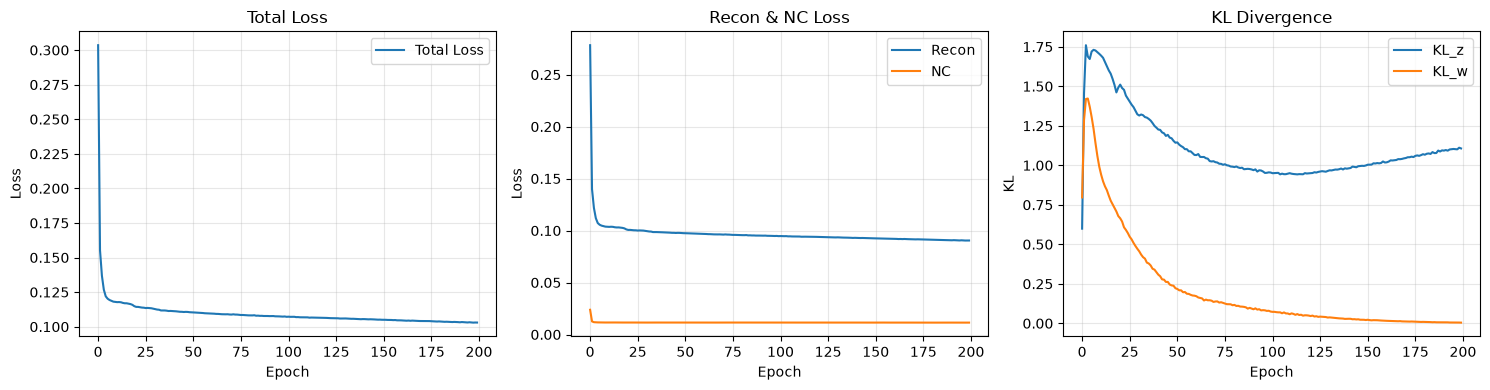

In [14]:
# ========== 4. 训练损失可视化 ==========
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(loss_history["total"], label="Total Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Total Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history["recon"], label="Recon")
axes[1].plot(loss_history["nc"], label="NC")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].set_title("Recon & NC Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(loss_history["kl_z"], label="KL_z")
axes[2].plot(loss_history["kl_w"], label="KL_w")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("KL"); axes[2].set_title("KL Divergence")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# ========== 5. 计算 DEG（在 CPU 上进行） ==========
import importlib
import model as model_module
importlib.reload(model_module)
from model import RUVVAE_DEG, compute_deg

model_cpu = model.cpu()
deg_df, extra = compute_deg(
    model_cpu,
    Y_log,
    gene_names,
    group_labels,
    groups_unique,
    neg_control_mask,
    batch_labels=batch_labels,
    n_genes_on=n_genes_on,
    n_posterior=200,
    n_perm=500,
)

print(f"DEG 结果: {deg_df.shape[0]} 个基因")
print(f"\n列名: {list(deg_df.columns)}")

# ---------- 5a. Top 20 DEG（按 biological logFC 排序） ----------
print("\nTop 20 genes (按 |logFC_bio| 排序):")
top_deg = (
    deg_df.assign(abs_logFC_bio=np.abs(deg_df["logFC_bio"]))
    .sort_values("abs_logFC_bio", ascending=False)
    .head(20)
)
display(top_deg[[
    "gene", "logFC_group", "logFC_bio_latent", "logFC_bio",
    "logFC_uv_n_genes_on", "logFC_uv_cov",
    "p_value_empirical_t", "p_value_perm",
]])

# ---------- 5b. 多种 p-value 方法的显著 DEG 数 + FDR 校正 ----------
from scipy.stats import false_discovery_control

p_methods = {
    "GLM delta (Wald)": "p_value_glm_delta",
    "Welch's t-test": "p_value_empirical_t",
    "Permutation (500x)": "p_value_perm",
    "Bayesian (后验符号)": "p_value_bayes",
}

print("\n=== 不同 p-value 方法的显著 DEG 数 + FDR 校正 ===")
print(f"{'方法':<24} {'p<0.05':>8} {'p<0.01':>8} {'FDR<0.05':>10} {'FDR<0.01':>10} {'FDR<0.10':>10}")
print("-" * 76)

deg_counts = {}
for name, col in p_methods.items():
    pvals = deg_df[col].values
    valid = ~np.isnan(pvals)
    fdr = np.full_like(pvals, np.nan)
    if valid.any():
        fdr[valid] = false_discovery_control(pvals[valid])
        deg_df[col.replace("p_value", "fdr")] = fdr
    n_sig = int((pvals < 0.05).sum())
    n_sig01 = int((pvals < 0.01).sum())
    n_fdr05 = int(((fdr < 0.05) & valid).sum())
    n_fdr01 = int(((fdr < 0.01) & valid).sum())
    n_fdr10 = int(((fdr < 0.10) & valid).sum())
    deg_counts[name] = {
        "p<0.05": n_sig, "p<0.01": n_sig01,
        "FDR<0.05": n_fdr05, "FDR<0.01": n_fdr01,
        "FDR<0.10": n_fdr10,
    }
    print(f"{name:<24} {n_sig:>8} {n_sig01:>8} {n_fdr05:>10} {n_fdr01:>10} {n_fdr10:>10}")

# ---------- 5c. 共识 DEG ----------
print("\n=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===")
consensus = (
    (deg_df["p_value_glm_delta"] < 0.05)
    & (deg_df["p_value_empirical_t"] < 0.05)
    & (deg_df["p_value_perm"] < 0.05)
)
deg_df["consensus_sig"] = consensus
print(f"共识 DEG: {consensus.sum()}")
print(f"  上调 (logFC_bio > 0): {(consensus & (deg_df['logFC_bio'] > 0)).sum()}")
print(f"  下调 (logFC_bio < 0): {(consensus & (deg_df['logFC_bio'] < 0)).sum()}")
print(
    "\n检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: "
    f"{np.mean(np.abs(deg_df['logFC_uv_n_genes_on'])):.4f}"
)


DEG 结果: 16428 个基因

列名: ['gene', 'logFC_group', 'logFC_bio_latent', 'logFC_bio', 'logFC_bio_posterior_mean', 'logFC_bio_posterior_std', 'logFC_bio_ci_low', 'logFC_bio_ci_high', 'logFC_uv_group', 'logFC_uv_linear', 'logFC_uv_n_genes_on', 'logFC_uv_latent', 'logFC_uv_cov', 'logFC_uv_total', 'logFC_uv_posterior_mean', 'logFC_uv_posterior_std', 'se_glm', 't_stat', 'p_value_bayes', 'p_value_empirical_t', 'p_value_glm_delta', 'p_value_perm']

Top 20 genes (按 |logFC_bio| 排序):


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_n_genes_on,logFC_uv_cov,p_value_empirical_t,p_value_perm
14544,Gm42418,1.391000,0.108722,1.499722,-0.217458,-1.133955,1.000000e-300,0.001996
13577,Rbfox1,0.105836,0.539348,0.645183,-0.014765,-0.124075,5.198536e-238,0.001996
7201,Fam155a,0.087293,0.506514,0.593807,-0.068649,-0.129436,5.026702e-262,0.001996
3620,Atp6v0b,-0.341971,-0.251775,-0.593746,-0.422297,-0.127232,1.000000e-300,0.001996
8528,Rora,0.118101,0.465741,0.583842,-0.047099,-0.154589,2.305859e-227,0.001996
4211,Dpp6,0.167041,0.408992,0.576033,-0.120597,-0.267378,1.000000e-300,0.001996
5719,Cacna1c,0.129437,0.442963,0.572400,-0.098738,-0.238574,4.569860e-225,0.001996
1019,Camk1d,0.337765,0.232837,0.570602,-0.161872,-0.451208,1.000000e-300,0.001996
13610,Shisa9,0.103881,0.455083,0.558964,-0.118363,-0.205451,4.552297e-247,0.001996
4377,Kcnip4,0.011290,0.540238,0.551528,0.090728,0.061880,3.604676e-145,0.001996



=== 不同 p-value 方法的显著 DEG 数 + FDR 校正 ===
方法                         p<0.05   p<0.01   FDR<0.05   FDR<0.01   FDR<0.10
----------------------------------------------------------------------------
GLM delta (Wald)            14950    14548      14922      14516      15149
Welch's t-test              11179    10284      10922      10034      11415
Permutation (500x)          14911    14456      14882      14406      15106
Bayesian (后验符号)             16192    16099      16192      16099      16234

=== 多方法共识 DEG（GLM & Welch & Permutation 都 p<0.05）===
共识 DEG: 11171
  上调 (logFC_bio > 0): 6327
  下调 (logFC_bio < 0): 4844

检测协变量 UV 贡献 mean |logFC_uv_n_genes_on|: 0.0652


In [16]:
# ========== 5e. 审计 group biological effect / UV 分解 ==========
# group 现在是生物学效应；UV 只包含 latent UV + batch covariate。
print("\n=== Group biological effect audit ===")
print(f"mean |logFC_group|: {np.mean(np.abs(deg_df['logFC_group'])):.4f}")
print(f"mean |logFC_bio_latent|: {np.mean(np.abs(deg_df['logFC_bio_latent'])):.4f}")
print(f"mean |logFC_uv_cov| (batch only): {np.mean(np.abs(deg_df['logFC_uv_cov'])):.4f}")
print("\nTop genes by explicit group effect:")
display(
    deg_df.assign(abs_group_effect=np.abs(deg_df["logFC_group"]))
    .nlargest(20, "abs_group_effect")
    [["gene", "logFC_group", "logFC_bio_latent", "logFC_bio", "logFC_uv_cov"]]
)
assert "logFC_group" in deg_df.columns
assert "logFC_uv_cov" in deg_df.columns
assert "logFC_uv_group" in deg_df.columns



=== Group biological effect audit ===
mean |logFC_group|: 0.0179
mean |logFC_bio_latent|: 0.0422
mean |logFC_uv_cov| (batch only): 0.0672

Top genes by explicit group effect:


,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_uv_cov
14544,Gm42418,1.391000,0.108722,1.499722,-1.133955
16274,Plp1,0.400710,-0.046678,0.354032,-0.387914
8075,Taf1d,-0.353817,-0.047287,-0.401104,-0.126044
7165,Bc1,0.344312,-0.145855,0.198457,-0.601153
3620,Atp6v0b,-0.341971,-0.251775,-0.593746,-0.127232
1019,Camk1d,0.337765,0.232837,0.570602,-0.451208
15895,Syp,-0.333700,0.337350,0.003650,-0.001312
2914,Rnpc3,-0.312806,-0.019170,-0.331976,-0.130294
8973,Lars2,0.312776,0.117171,0.429947,-0.397104
14545,AY036118,0.310123,-0.033640,0.276484,-0.348038


In [25]:
deg_df[np.abs(deg_df.logFC_bio)>0.1]

,gene,logFC_group,logFC_bio_latent,logFC_bio,logFC_bio_posterior_mean,logFC_bio_posterior_std,logFC_bio_ci_low,logFC_bio_ci_high,logFC_uv_group,logFC_uv_linear,...,t_stat,p_value_bayes,p_value_empirical_t,p_value_glm_delta,p_value_perm,fdr_glm_delta,fdr_empirical_t,fdr_perm,fdr_bayes,consensus_sig
0,Xkr4,0.029975,0.467771,0.497746,0.610682,0.001304,0.608133,0.613188,0.0,-0.113476,...,33.272484,0.0,8.424932e-212,9.656819e-243,0.001996,1.307850e-241,6.437432e-210,0.002336,0.0,True
2,Gm19938,-0.012850,0.194400,0.181550,0.249382,0.000663,0.247992,0.250819,0.0,-0.068531,...,26.458820,0.0,1.047671e-125,2.888430e-154,0.001996,1.734325e-153,1.792827e-124,0.002336,0.0,True
8,Atp6v1h,-0.007933,0.159118,0.151186,0.248717,0.000638,0.247608,0.249921,0.0,-0.098506,...,27.500195,0.0,2.437915e-115,1.746254e-166,0.001996,1.175234e-165,3.704910e-114,0.002336,0.0,True
10,Rb1cc1,-0.021654,0.183016,0.161362,0.344291,0.000603,0.343165,0.345444,0.0,-0.183134,...,29.517595,0.0,1.716471e-126,1.711918e-191,0.001996,1.459439e-190,2.980780e-125,0.002336,0.0,True
11,4732440D04Rik,-0.048146,-0.077780,-0.125925,-0.016576,0.000558,-0.017665,-0.015532,0.0,-0.110022,...,-37.389000,0.0,1.399057e-69,1.000000e-300,0.001996,2.380870e-299,1.185339e-68,0.002336,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16369,Cdkl5,0.040126,0.276424,0.316550,0.452484,0.001183,0.450017,0.454760,0.0,-0.136269,...,29.811350,0.0,4.213375e-171,2.784310e-195,0.001996,2.455214e-194,1.421300e-169,0.002336,0.0,True
16373,Reps2,0.005529,0.207845,0.213374,0.370756,0.000762,0.369347,0.372379,0.0,-0.157819,...,27.480801,0.0,3.699331e-140,2.978218e-166,0.001996,1.999435e-165,7.933761e-139,0.002336,0.0,True
16378,Ctps2,0.040778,0.086114,0.126892,0.279436,0.000698,0.277969,0.280737,0.0,-0.152932,...,30.026554,0.0,1.418433e-91,4.418910e-198,0.001996,3.979926e-197,1.585172e-90,0.002336,0.0,True
16401,Frmpd4,0.009966,0.376218,0.386184,0.521372,0.001263,0.519088,0.524013,0.0,-0.134824,...,31.499201,0.0,9.849831e-191,8.908138e-218,0.001996,9.615170e-217,5.040904e-189,0.002336,0.0,True


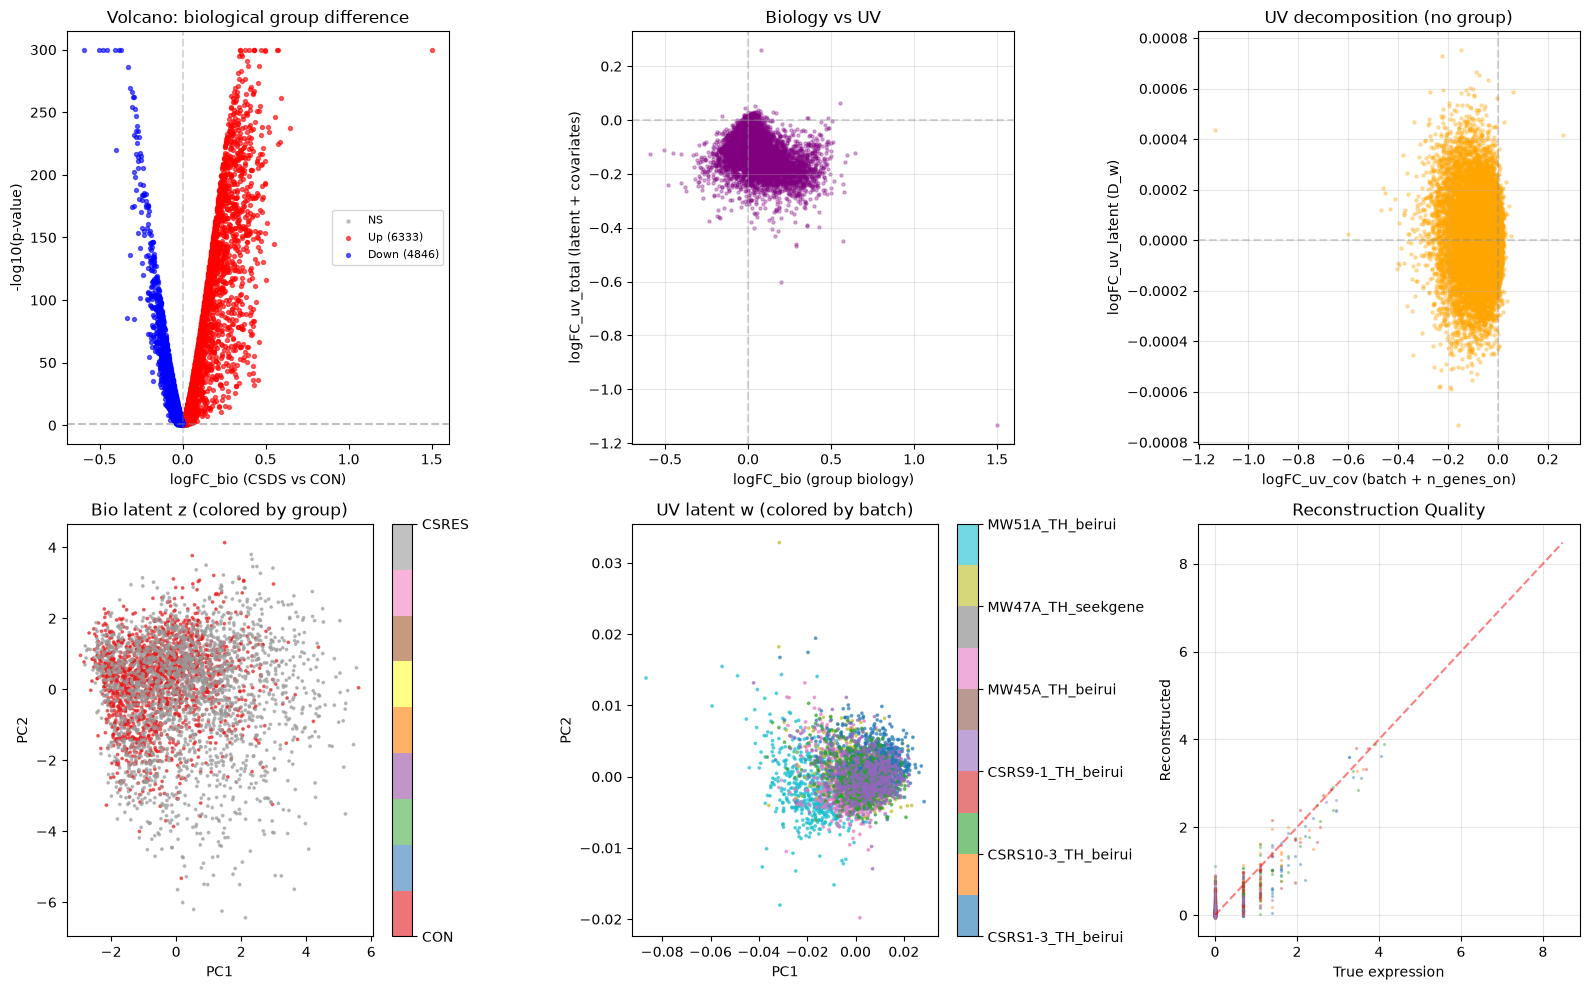

In [18]:
# ========== 6. 结果可视化：明确区分 group biology 与 UV ==========
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 6a. Volcano plot：总 biological logFC（包含显式 group effect）
ax = axes[0, 0]
logFC = deg_df["logFC_bio"].values
pval = deg_df["p_value_empirical_t"].values
neg_log_p = -np.log10(pval + 1e-300)
sig_up = (pval < 0.05) & (logFC > 0)
sig_down = (pval < 0.05) & (logFC < 0)
ax.scatter(logFC[~sig_up & ~sig_down], neg_log_p[~sig_up & ~sig_down], c="gray", alpha=0.4, s=5, label="NS")
ax.scatter(logFC[sig_up], neg_log_p[sig_up], c="red", alpha=0.6, s=8, label=f"Up ({sig_up.sum()})")
ax.scatter(logFC[sig_down], neg_log_p[sig_down], c="blue", alpha=0.6, s=8, label=f"Down ({sig_down.sum()})")
ax.axhline(-np.log10(0.05), c="gray", ls="--", alpha=0.5)
ax.axvline(0, c="gray", ls="--", alpha=0.3)
ax.set_xlabel("logFC_bio (CSDS vs CON)"); ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano: biological group difference"); ax.legend(fontsize=8)

# 6b. Biological effect vs total UV
ax = axes[0, 1]
ax.scatter(deg_df["logFC_bio"], deg_df["logFC_uv_total"], alpha=0.3, s=5, c="purple")
ax.set_xlabel("logFC_bio (group biology)"); ax.set_ylabel("logFC_uv_total (latent + covariates)")
ax.set_title("Biology vs UV"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6c. UV 分解：batch + n_genes_on 与 latent UV，不包含 group
ax = axes[0, 2]
ax.scatter(deg_df["logFC_uv_cov"], deg_df["logFC_uv_latent"], alpha=0.3, s=5, c="orange")
ax.set_xlabel("logFC_uv_cov (batch + n_genes_on)"); ax.set_ylabel("logFC_uv_latent (D_w)")
ax.set_title("UV decomposition (no group)"); ax.grid(True, alpha=0.3)
ax.axhline(0, c="gray", ls="--", alpha=0.3); ax.axvline(0, c="gray", ls="--", alpha=0.3)

# 6d. 生物学潜变量 z 的 PCA（按 group 着色）
z_mu = np.nan_to_num(extra["z_mu"], nan=0.0)
from sklearn.decomposition import PCA
z_pca = PCA(n_components=2).fit_transform(z_mu)
scatter = axes[1, 0].scatter(
    z_pca[:, 0], z_pca[:, 1],
    c=[groups_unique.index(g) for g in group_labels],
    cmap="Set1", s=3, alpha=0.6,
)
axes[1, 0].set_title("Bio latent z (colored by group)")
axes[1, 0].set_xlabel("PC1"); axes[1, 0].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 0], ticks=range(len(groups_unique)))
cbar.set_ticklabels(groups_unique)

# 6e. UV 潜变量 w 的 PCA（按 batch 着色）
w_mu = np.nan_to_num(extra["w_mu"], nan=0.0)
w_pca = PCA(n_components=2).fit_transform(w_mu)
scatter = axes[1, 1].scatter(
    w_pca[:, 0], w_pca[:, 1],
    c=[batches_unique.index(b) for b in batch_labels],
    cmap="tab10", s=3, alpha=0.6,
)
axes[1, 1].set_title("UV latent w (colored by batch)")
axes[1, 1].set_xlabel("PC1"); axes[1, 1].set_ylabel("PC2")
cbar = plt.colorbar(scatter, ax=axes[1, 1], ticks=range(len(batches_unique)))
cbar.set_ticklabels(batches_unique)

# 6f. 重建质量
ax = axes[1, 2]
model_cpu.eval()
with torch.no_grad():
    c_dict_cpu = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out = model_cpu(torch.FloatTensor(Y_log), c_dict_cpu, torch.BoolTensor(neg_control_mask))
    y_recon = out["y_recon"].numpy()
idx_plot = np.random.choice(Y_log.shape[0], min(200, Y_log.shape[0]), replace=False)
for i in idx_plot[:5]:
    ax.scatter(Y_log[i, :200], y_recon[i, :200], s=2, alpha=0.3)
ax.plot([0, Y_log.max()], [0, Y_log.max()], "r--", alpha=0.5)
ax.set_xlabel("True expression"); ax.set_ylabel("Reconstructed")
ax.set_title("Reconstruction Quality"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
def compute_metrics(y_t, y_p):
    """向量化 R² + Pearson r（按基因 / 按样本 / 整体），无 for 循环"""
    # 整体 R²
    r2_total = float(r2_score(y_t.ravel(), y_p.ravel()))

    # 向量化按基因 Pearson r
    yt = y_t - y_t.mean(axis=0, keepdims=True)
    yp = y_p - y_p.mean(axis=0, keepdims=True)
    pearson_per_gene = (yt * yp).sum(axis=0) / \
        (np.sqrt((yt ** 2).sum(axis=0) * (yp ** 2).sum(axis=0)) + 1e-12)

    # 向量化按样本 Pearson r
    yt_c = y_t - y_t.mean(axis=1, keepdims=True)
    yp_c = y_p - y_p.mean(axis=1, keepdims=True)
    pearson_per_cell = (yt_c * yp_c).sum(axis=1) / \
        (np.sqrt((yt_c ** 2).sum(axis=1) * (yp_c ** 2).sum(axis=1)) + 1e-12)

    # 向量化按基因 R²
    ss_res_g = ((y_t - y_p) ** 2).sum(axis=0)
    ss_tot_g = ((y_t - y_t.mean(axis=0, keepdims=True)) ** 2).sum(axis=0) + 1e-12
    r2_per_gene = 1.0 - ss_res_g / ss_tot_g

    # 向量化按样本 R²
    ss_res_c = ((y_t - y_p) ** 2).sum(axis=1)
    ss_tot_c = ((y_t - y_t.mean(axis=1, keepdims=True)) ** 2).sum(axis=1) + 1e-12
    r2_per_cell = 1.0 - ss_res_c / ss_tot_c

    return {
        "r2_total": r2_total,
        "r2_per_gene_mean": float(np.mean(r2_per_gene)),
        "r2_per_gene_median": float(np.median(r2_per_gene)),
        "r2_per_cell_mean": float(np.mean(r2_per_cell)),
        "r2_per_cell_median": float(np.median(r2_per_cell)),
        "pearson_per_gene_mean": float(np.mean(pearson_per_gene)),
        "pearson_per_gene_median": float(np.median(pearson_per_gene)),
        "pearson_per_cell_mean": float(np.mean(pearson_per_cell)),
        "pearson_per_cell_median": float(np.median(pearson_per_cell)),
    }

In [20]:
# ========== 7. Reconstruction Quality Evaluation: R² + Pearson r ==========
from sklearn.metrics import r2_score
import torch
import numpy as np
import matplotlib.pyplot as plt

model_cpu.eval()
with torch.no_grad():
    group_idx = np.array([groups_unique.index(g) for g in group_labels])
    batch_idx = np.array([batches_unique.index(b) for b in batch_labels])
    c_dict_eval = {
        "group": torch.FloatTensor(np.eye(len(groups_unique))[group_idx]),
        "batch": torch.FloatTensor(np.eye(len(batches_unique))[batch_idx]),
        "n_genes_on": torch.FloatTensor(n_genes_on[:, None]),
    }
    out_eval = model_cpu(torch.FloatTensor(Y_log), c_dict_eval, torch.BoolTensor(neg_control_mask))
    y_recon_eval = out_eval["y_recon"].numpy()
    y_bio_eval = out_eval["y_bio"].numpy()

y_true = Y_log

print("=== Reconstruction Quality Evaluation ===\n")
metrics_recon = compute_metrics(y_true, y_recon_eval)
metrics_clean = compute_metrics(y_true, y_bio_eval)

print("[Overall Reconstruction y_recon = y_bio - delta_lat - delta_cov]")
for k, v in metrics_recon.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n[Biological Channel y_bio (Direct VAE output)]")
for k, v in metrics_clean.items():
    print(f"  {k:<28}: {v:.4f}")

print("\n=== Reconstruction Quality Summary ===")
print(f"{'Metric':<35} {'y_recon (w/ UV)':>18} {'y_bio (Clean)':>18}")
print("-" * 75)
for k in metrics_recon:
    print(f"{k:<35} {metrics_recon[k]:>18.4f} {metrics_clean[k]:>18.4f}")


=== Reconstruction Quality Evaluation ===

[Overall Reconstruction y_recon = y_bio - delta_lat - delta_cov]
  r2_total                    : 0.7167
  r2_per_gene_mean            : -54001524.0000
  r2_per_gene_median          : 0.0925
  r2_per_cell_mean            : 0.6824
  r2_per_cell_median          : 0.6825
  pearson_per_gene_mean       : 0.3516
  pearson_per_gene_median     : 0.3085
  pearson_per_cell_mean       : 0.8251
  pearson_per_cell_median     : 0.8262

[Biological Channel y_bio (Direct VAE output)]
  r2_total                    : 0.3432
  r2_per_gene_mean            : -52406004.0000
  r2_per_gene_median          : -0.1011
  r2_per_cell_mean            : 0.2982
  r2_per_cell_median          : 0.3033
  pearson_per_gene_mean       : 0.2888
  pearson_per_gene_median     : 0.2453
  pearson_per_cell_mean       : 0.7187
  pearson_per_cell_median     : 0.7531

=== Reconstruction Quality Summary ===
Metric                                 y_recon (w/ UV)      y_bio (Clean)
-----------